<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/research-v2/notebooks/18_v2_fresh_acceptance_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 18: Fresh On-Policy Acceptance Benchmark

This notebook evaluates four latent transition models:

1. One-step
2. Multi-step
3. On-policy latent
4. Survival-weighted decoder-aware

Unlike the offline diagnostics, every model generates fresh draft tokens
from its own distribution. DistilGPT-2 acts as the target verifier.

Primary metrics:

- mean accepted prefix;
- mean accepted tokens beyond the first;
- full-prefix acceptance rate;
- acceptance rate by position;
- output KL by position;
- paired prompt-level bootstrap confidence intervals.

The central hypothesis is:

> Survival-weighted decoder-aware training improves fresh speculative
> acceptance, rather than only reducing KL on fixed behavior trajectories.

In [1]:
!pip -q install transformers datasets pandas matplotlib seaborn scipy scikit-learn

In [2]:
import os
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)

assert PROJECT_DIR.exists(), (
    f"Project directory does not exist: {PROJECT_DIR}"
)

print("Project directory:")
print(PROJECT_DIR)

print("\n========== CHECKPOINT FILES ==========")

checkpoint_files = sorted(
    list(PROJECT_DIR.rglob("*.pt"))
    + list(PROJECT_DIR.rglob("*.pth"))
)

for index, path in enumerate(checkpoint_files):
    size_mb = path.stat().st_size / (1024 ** 2)

    print(
        f"[{index:02d}] "
        f"{path.relative_to(PROJECT_DIR)} "
        f"({size_mb:.2f} MB)"
    )

print("\nTotal checkpoint/data files:",
      len(checkpoint_files))

Project directory:
/content/drive/MyDrive/ma2288_nextlat

========== CHECKPOINT FILES ==========
[00] checkpoints/multistep_transition_seed42.pt (4.52 MB)
[01] checkpoints/one_step_transition_seed42.pt (4.52 MB)
[02] checkpoints_v2/onpolicy_latent_transition_seed42.pt (4.52 MB)
[03] checkpoints_v2/survival_weighted_transition_seed42.pt (4.53 MB)
[04] data_v2/onpolicy_rollouts_seed42.pt (20.01 MB)
[05] test_teacher_states.pt (7.54 MB)
[06] train_teacher_states.pt (37.70 MB)
[07] validation_teacher_states.pt (7.54 MB)

Total checkpoint/data files: 8


In [5]:
def classify_checkpoint(path):
    name = path.name.lower()
    full_path = str(path).lower()

    if "survival" in name:
        return "Survival-weighted"

    if "onpolicy" in name or "on_policy" in name:
        if "rollout" not in name:
            return "On-policy latent"

    if "multistep" in name or "multi_step" in name:
        return "Multi-step"

    if "one_step" in name or "onestep" in name:
        return "One-step"

    return None


checkpoint_candidates = []

for path in checkpoint_files:
    method = classify_checkpoint(path)

    if method is not None:
        checkpoint_candidates.append({
            "method": method,
            "path": str(path),
            "size_mb":
                path.stat().st_size / (1024 ** 2),
        })

candidate_df = pd.DataFrame(checkpoint_candidates)

if len(candidate_df) == 0:
    print("No model checkpoint candidates found.")
else:
    display(
        candidate_df.sort_values(
            ["method", "path"]
        ).reset_index(drop=True)
    )

,method,path,size_mb
0,Multi-step,/content/drive/MyDrive/ma2288_nextlat/checkpoi...,4.520818
1,On-policy latent,/content/drive/MyDrive/ma2288_nextlat/checkpoi...,4.521985
2,One-step,/content/drive/MyDrive/ma2288_nextlat/checkpoi...,4.521295
3,Survival-weighted,/content/drive/MyDrive/ma2288_nextlat/checkpoi...,4.525449


In [6]:
def summarize_object(value):
    if isinstance(value, torch.Tensor):
        return {
            "type": "Tensor",
            "shape": tuple(value.shape),
            "dtype": str(value.dtype),
        }

    if isinstance(value, dict):
        return {
            "type": "dict",
            "num_keys": len(value),
            "first_keys": list(value.keys())[:15],
        }

    if isinstance(value, list):
        return {
            "type": "list",
            "length": len(value),
        }

    return {
        "type": type(value).__name__,
        "value": str(value)[:200],
    }


for row in checkpoint_candidates:
    path = Path(row["path"])

    print("\n" + "=" * 80)
    print("Method:", row["method"])
    print("File:", path)

    try:
        obj = torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )

        print("Top-level summary:")
        print(summarize_object(obj))

        if isinstance(obj, dict):
            print("\nTop-level contents:")

            for key, value in obj.items():
                print(
                    f"  {key}: "
                    f"{summarize_object(value)}"
                )

    except Exception as error:
        print("Could not load:", repr(error))


Method: Multi-step
File: /content/drive/MyDrive/ma2288_nextlat/checkpoints/multistep_transition_seed42.pt
Top-level summary:
{'type': 'dict', 'num_keys': 10, 'first_keys': ['model_state_dict', 'model_name', 'hidden_dimension', 'bottleneck_dimension', 'seed', 'rollout_length', 'learning_rate', 'initial_checkpoint', 'best_validation_rollout_loss', 'training_history']}

Top-level contents:
  model_state_dict: {'type': 'dict', 'num_keys': 6, 'first_keys': ['input_normalization.weight', 'input_normalization.bias', 'network.0.weight', 'network.0.bias', 'network.2.weight', 'network.2.bias']}
  model_name: {'type': 'str', 'value': 'distilgpt2'}
  hidden_dimension: {'type': 'int', 'value': '768'}
  bottleneck_dimension: {'type': 'int', 'value': '512'}
  seed: {'type': 'int', 'value': '42'}
  rollout_length: {'type': 'int', 'value': '8'}
  learning_rate: {'type': 'float', 'value': '0.0002'}
  initial_checkpoint: {'type': 'str', 'value': 'one_step_transition_seed42.pt'}
  best_validation_rollout

In [7]:
possible_rollout_files = [
    path
    for path in checkpoint_files
    if (
        "rollout" in path.name.lower()
        or "onpolicy" in path.name.lower()
        or "on_policy" in path.name.lower()
    )
]

print("Possible rollout files:")

for index, path in enumerate(possible_rollout_files):
    print(f"[{index}] {path}")

for path in possible_rollout_files:
    print("\n" + "=" * 80)
    print("Inspecting:", path)

    try:
        obj = torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )

        if not isinstance(obj, dict):
            print("Not a dictionary.")
            continue

        print("Keys:")

        for key, value in obj.items():
            print(
                f"  {key}: "
                f"{summarize_object(value)}"
            )

        context_keys = [
            key
            for key in obj.keys()
            if any(
                word in key.lower()
                for word in [
                    "prompt_token",
                    "prefix_token",
                    "context_token",
                    "input_ids",
                    "attention_mask",
                    "past_key",
                    "cache",
                ]
            )
        ]

        print("Possible context keys:", context_keys)

    except Exception as error:
        print("Could not load:", repr(error))

Possible rollout files:
[0] /content/drive/MyDrive/ma2288_nextlat/checkpoints_v2/onpolicy_latent_transition_seed42.pt
[1] /content/drive/MyDrive/ma2288_nextlat/data_v2/onpolicy_rollouts_seed42.pt

Inspecting: /content/drive/MyDrive/ma2288_nextlat/checkpoints_v2/onpolicy_latent_transition_seed42.pt
Keys:
  model_state_dict: {'type': 'dict', 'num_keys': 6, 'first_keys': ['input_normalization.weight', 'input_normalization.bias', 'network.0.weight', 'network.0.bias', 'network.2.weight', 'network.2.bias']}
  model_name: {'type': 'str', 'value': 'distilgpt2'}
  hidden_dimension: {'type': 'int', 'value': '768'}
  bottleneck_dimension: {'type': 'int', 'value': '512'}
  seed: {'type': 'int', 'value': '42'}
  rollout_length: {'type': 'int', 'value': '8'}
  learning_rate: {'type': 'float', 'value': '0.0001'}
  initial_checkpoint: {'type': 'str', 'value': 'multistep_transition_seed42.pt'}
  training_data: {'type': 'str', 'value': 'onpolicy_rollouts_seed42.pt'}
  best_validation_loss: {'type': 'flo

In [8]:
CHECKPOINT_PATHS = {
    "One-step": (
        PROJECT_DIR
        / "checkpoints"
        / "one_step_transition_seed42.pt"
    ),

    "Multi-step": (
        PROJECT_DIR
        / "checkpoints"
        / "multistep_transition_seed42.pt"
    ),

    "On-policy latent": (
        PROJECT_DIR
        / "checkpoints_v2"
        / "onpolicy_latent_transition_seed42.pt"
    ),

    "Survival-weighted": (
        PROJECT_DIR
        / "checkpoints_v2"
        / "survival_weighted_transition_seed42.pt"
    ),
}

for method, path in CHECKPOINT_PATHS.items():
    assert path.exists(), f"Missing {method}: {path}"
    print(f"{method}: {path}")

One-step: /content/drive/MyDrive/ma2288_nextlat/checkpoints/one_step_transition_seed42.pt
Multi-step: /content/drive/MyDrive/ma2288_nextlat/checkpoints/multistep_transition_seed42.pt
On-policy latent: /content/drive/MyDrive/ma2288_nextlat/checkpoints_v2/onpolicy_latent_transition_seed42.pt
Survival-weighted: /content/drive/MyDrive/ma2288_nextlat/checkpoints_v2/survival_weighted_transition_seed42.pt


In [9]:
MODEL_NAME = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

target_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
).to(device)

target_model.eval()

for parameter in target_model.parameters():
    parameter.requires_grad = False

token_embedding = target_model.get_input_embeddings()

print("Model:", MODEL_NAME)
print("Vocabulary size:", target_model.config.vocab_size)
print("Hidden size:", target_model.config.n_embd)
print("EOS token:", tokenizer.eos_token)
print("EOS token ID:", tokenizer.eos_token_id)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: distilgpt2
Vocabulary size: 50257
Hidden size: 768
EOS token: <|endoftext|>
EOS token ID: 50256


In [10]:
class ResidualLatentTransition(nn.Module):
    def __init__(
        self,
        hidden_size=768,
        token_embedding_size=768,
        intermediate_size=512,
    ):
        super().__init__()

        input_size = (
            hidden_size + token_embedding_size
        )

        self.input_normalization = nn.LayerNorm(
            input_size
        )

        self.network = nn.Sequential(
            nn.Linear(
                input_size,
                intermediate_size,
            ),
            nn.GELU(),
            nn.Linear(
                intermediate_size,
                hidden_size,
            ),
        )

    def forward(
        self,
        hidden_state,
        token_embedding_value,
    ):
        model_input = torch.cat(
            [
                hidden_state,
                token_embedding_value,
            ],
            dim=-1,
        )

        normalized_input = self.input_normalization(
            model_input
        )

        delta = self.network(
            normalized_input
        )

        return hidden_state + delta

In [11]:
transition_models = {}

for method, checkpoint_path in CHECKPOINT_PATHS.items():
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    assert "model_state_dict" in checkpoint

    transition_model = ResidualLatentTransition(
        hidden_size=768,
        token_embedding_size=768,
        intermediate_size=512,
    ).to(device)

    load_result = transition_model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True,
    )

    assert len(load_result.missing_keys) == 0
    assert len(load_result.unexpected_keys) == 0

    transition_model.eval()

    for parameter in transition_model.parameters():
        parameter.requires_grad = False

    transition_models[method] = transition_model

    print(
        f"{method}: loaded successfully "
        f"from {checkpoint_path.name}"
    )

print("\nLoaded models:", list(transition_models.keys()))

One-step: loaded successfully from one_step_transition_seed42.pt
Multi-step: loaded successfully from multistep_transition_seed42.pt
On-policy latent: loaded successfully from onpolicy_latent_transition_seed42.pt
Survival-weighted: loaded successfully from survival_weighted_transition_seed42.pt

Loaded models: ['One-step', 'Multi-step', 'On-policy latent', 'Survival-weighted']


In [12]:
from datasets import load_dataset

evaluation_dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-103-raw-v1",
    split="test",
)

print(evaluation_dataset)
print("Number of text rows:", len(evaluation_dataset))
print("\nFirst non-empty examples:")

shown = 0

for row in evaluation_dataset:
    text_value = row["text"].strip()

    if len(text_value) > 50:
        print(repr(text_value[:200]))
        shown += 1

    if shown == 3:
        break

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-103-raw-v1/test-00000-of-00001.(…): downloading bytes:           |  0.00B            

wikitext-103-raw-v1/train-00000-of-00002(…): reconstructing file:   0%|          |  0.00B /  157MB            

wikitext-103-raw-v1/train-00000-of-00002(…): downloading bytes:           |  0.00B            

...

wikitext-103-raw-v1/validation-00000-of-(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Dataset({
    features: ['text'],
    num_rows: 4358
})
Number of text rows: 4358

First non-empty examples:
'Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This was followed by a starring role in the play Herons '
'In 2006 , Boulter starred alongside Whishaw in the play Citizenship written by Mark Ravenhill . He appeared on a 2006 episode of the television series , Doctors , followed by a role in the 2007 theatr'
'In 2000 Boulter had a guest @-@ starring role on the television series The Bill ; he portrayed " Scott Parry " in the episode , " In Safe Hands " . Boulter starred as " Scott " in the play Herons writ'


In [13]:
NUM_PROMPTS = 80
PREFIX_LENGTH = 32
PROMPT_STRIDE = 64
TOKEN_OFFSET = 2048

nonempty_texts = [
    row["text"].strip()
    for row in evaluation_dataset
    if len(row["text"].strip()) > 0
]

separator = tokenizer.eos_token or "\n"

combined_text = separator.join(nonempty_texts)

encoded_stream = tokenizer(
    combined_text,
    add_special_tokens=False,
    return_tensors="pt",
)["input_ids"][0]

required_tokens = (
    TOKEN_OFFSET
    + (NUM_PROMPTS - 1) * PROMPT_STRIDE
    + PREFIX_LENGTH
)

assert encoded_stream.numel() >= required_tokens

prompt_token_ids = torch.stack([
    encoded_stream[
        TOKEN_OFFSET + index * PROMPT_STRIDE:
        TOKEN_OFFSET + index * PROMPT_STRIDE
        + PREFIX_LENGTH
    ]
    for index in range(NUM_PROMPTS)
])

assert prompt_token_ids.shape == (
    NUM_PROMPTS,
    PREFIX_LENGTH,
)

print("Prompt token shape:", prompt_token_ids.shape)

for index in range(3):
    print(f"\nPrompt {index}:")
    print(
        tokenizer.decode(
            prompt_token_ids[index].tolist()
        )
    )

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (280743 > 1024). Running this sequence through the model will result in indexing errors


Prompt token shape: torch.Size([80, 32])

Prompt 0:
 .<|endoftext|>His father died around 740 . Du Fu would have been allowed to enter the civil service because of his father 's rank , but he is thought

Prompt 1:
 in domestic affairs .<|endoftext|>In the autumn of 744 , he met Li Bai ( Li Po ) for the first time , and the two poets formed a friendship

Prompt 2:
 poet @-@ scholar life to which he was attracted after his failure in the civil service exam . The relationship was somewhat one @-@ sided , however .


In [14]:
EVALUATION_DATA_DIR = (
    PROJECT_DIR / "data_v2"
)

EVALUATION_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROMPT_PATH = (
    EVALUATION_DATA_DIR
    / "fresh_wikitext103_prompts_seed42.pt"
)

torch.save(
    {
        "token_ids": prompt_token_ids,
        "dataset": "wikitext-103-raw-v1",
        "split": "test",
        "num_prompts": NUM_PROMPTS,
        "prefix_length": PREFIX_LENGTH,
        "stride": PROMPT_STRIDE,
        "token_offset": TOKEN_OFFSET,
        "seed": SEED,
    },
    PROMPT_PATH,
)

print("Saved prompts:")
print(PROMPT_PATH)

Saved prompts:
/content/drive/MyDrive/ma2288_nextlat/data_v2/fresh_wikitext103_prompts_seed42.pt


In [15]:
@torch.inference_mode()
def get_target_state_and_logits(input_ids):
    transformer_output = target_model.transformer(
        input_ids=input_ids,
        attention_mask=torch.ones_like(input_ids),
        return_dict=True,
    )

    last_hidden = (
        transformer_output
        .last_hidden_state[:, -1, :]
        .float()
    )

    last_logits = target_model.lm_head(
        last_hidden
    ).float()

    return last_hidden, last_logits

In [16]:
small_prompt_batch = prompt_token_ids[:4].to(device)

with torch.inference_mode():
    initial_hidden, target_logits = (
        get_target_state_and_logits(
            small_prompt_batch
        )
    )

    reconstructed_logits = target_model.lm_head(
        initial_hidden
    ).float()

maximum_logit_difference = (
    target_logits - reconstructed_logits
).abs().max().item()

print("Initial hidden shape:", initial_hidden.shape)
print("Target logits shape:", target_logits.shape)
print(
    "Maximum logit reconstruction difference:",
    maximum_logit_difference,
)

assert maximum_logit_difference < 1e-4

Initial hidden shape: torch.Size([4, 768])
Target logits shape: torch.Size([4, 50257])
Maximum logit reconstruction difference: 0.0


In [17]:
ROLLOUT_LENGTH = 8
TRIALS_PER_PROMPT = 5
EVALUATION_BATCH_SIZE = 10
EPSILON = 1e-8

NUM_CHAINS = (
    NUM_PROMPTS * TRIALS_PER_PROMPT
)

expanded_prompt_tokens = (
    prompt_token_ids.repeat_interleave(
        TRIALS_PER_PROMPT,
        dim=0,
    )
)

expanded_prompt_indices = (
    torch.arange(NUM_PROMPTS)
    .repeat_interleave(TRIALS_PER_PROMPT)
)

expanded_trial_indices = (
    torch.arange(TRIALS_PER_PROMPT)
    .repeat(NUM_PROMPTS)
)

assert expanded_prompt_tokens.shape == (
    NUM_CHAINS,
    PREFIX_LENGTH,
)

print("Number of prompts:", NUM_PROMPTS)
print("Trials per prompt:", TRIALS_PER_PROMPT)
print("Total chains:", NUM_CHAINS)
print("Rollout length:", ROLLOUT_LENGTH)

Number of prompts: 80
Trials per prompt: 5
Total chains: 400
Rollout length: 8


In [18]:
@torch.inference_mode()
def evaluate_fresh_rollouts(
    method_name,
    transition_model,
    prompt_tokens,
    prompt_indices,
    trial_indices,
    batch_size=10,
    rollout_length=8,
    seed=42,
):
    transition_model.eval()

    num_chains = prompt_tokens.shape[0]

    all_records = []
    all_prefix_lengths = []

    # Each model gets the same random-number seed.
    sampling_generator = torch.Generator(
        device=device.type
    )
    sampling_generator.manual_seed(seed + 1000)

    acceptance_generator = torch.Generator(
        device=device.type
    )
    acceptance_generator.manual_seed(seed + 2000)

    for batch_start in range(
        0,
        num_chains,
        batch_size,
    ):
        batch_end = min(
            batch_start + batch_size,
            num_chains,
        )

        current_context = prompt_tokens[
            batch_start:batch_end
        ].to(device)

        current_prompt_indices = prompt_indices[
            batch_start:batch_end
        ]

        current_trial_indices = trial_indices[
            batch_start:batch_end
        ]

        current_batch_size = (
            current_context.shape[0]
        )

        target_hidden, target_logits = (
            get_target_state_and_logits(
                current_context
            )
        )

        draft_hidden = target_hidden.clone()

        still_alive = torch.ones(
            current_batch_size,
            dtype=torch.bool,
            device=device,
        )

        accepted_prefix_length = torch.zeros(
            current_batch_size,
            dtype=torch.long,
            device=device,
        )

        for step in range(rollout_length):
            draft_logits = target_model.lm_head(
                draft_hidden
            ).float()

            target_log_prob = F.log_softmax(
                target_logits,
                dim=-1,
            )

            draft_log_prob = F.log_softmax(
                draft_logits,
                dim=-1,
            )

            target_probability = (
                target_log_prob.exp()
            )

            draft_probability = (
                draft_log_prob.exp()
            )

            sampled_token_ids = torch.multinomial(
                draft_probability,
                num_samples=1,
                replacement=True,
                generator=sampling_generator,
            ).squeeze(1)

            selected_target_probability = (
                target_probability
                .gather(
                    1,
                    sampled_token_ids.unsqueeze(1),
                )
                .squeeze(1)
            )

            selected_draft_probability = (
                draft_probability
                .gather(
                    1,
                    sampled_token_ids.unsqueeze(1),
                )
                .squeeze(1)
            )

            acceptance_probability = torch.minimum(
                torch.ones_like(
                    selected_target_probability
                ),
                selected_target_probability
                / selected_draft_probability.clamp_min(
                    EPSILON
                ),
            )

            acceptance_uniform = torch.rand(
                current_batch_size,
                generator=acceptance_generator,
                device=device,
            )

            accepted_at_step = (
                acceptance_uniform
                < acceptance_probability
            )

            contributes_to_prefix = (
                still_alive & accepted_at_step
            )

            accepted_prefix_length += (
                contributes_to_prefix.long()
            )

            still_alive = (
                still_alive & accepted_at_step
            )

            output_kl = torch.sum(
                target_probability
                * (
                    target_log_prob
                    - draft_log_prob
                ),
                dim=-1,
            )

            top1_agreement = (
                target_logits.argmax(dim=-1)
                == draft_logits.argmax(dim=-1)
            )

            token_embeddings = token_embedding(
                sampled_token_ids
            ).float()

            next_draft_hidden = transition_model(
                draft_hidden,
                token_embeddings,
            )

            current_context = torch.cat(
                [
                    current_context,
                    sampled_token_ids.unsqueeze(1),
                ],
                dim=1,
            )

            next_target_hidden, next_target_logits = (
                get_target_state_and_logits(
                    current_context
                )
            )

            latent_difference = (
                next_draft_hidden
                - next_target_hidden
            )

            normalized_l2 = (
                latent_difference.norm(dim=-1)
                / next_target_hidden.norm(
                    dim=-1
                ).clamp_min(EPSILON)
            )

            for local_index in range(
                current_batch_size
            ):
                all_records.append({
                    "method": method_name,
                    "chain_index":
                        batch_start + local_index,
                    "prompt_index":
                        int(
                            current_prompt_indices[
                                local_index
                            ]
                        ),
                    "trial_index":
                        int(
                            current_trial_indices[
                                local_index
                            ]
                        ),
                    "step": step + 1,
                    "draft_token_id":
                        int(
                            sampled_token_ids[
                                local_index
                            ].cpu()
                        ),
                    "acceptance_probability":
                        float(
                            acceptance_probability[
                                local_index
                            ].cpu()
                        ),
                    "accepted_at_step":
                        bool(
                            accepted_at_step[
                                local_index
                            ].cpu()
                        ),
                    "survived_through_step":
                        bool(
                            still_alive[
                                local_index
                            ].cpu()
                        ),
                    "output_kl":
                        float(
                            output_kl[
                                local_index
                            ].cpu()
                        ),
                    "normalized_l2":
                        float(
                            normalized_l2[
                                local_index
                            ].cpu()
                        ),
                    "top1_agreement":
                        bool(
                            top1_agreement[
                                local_index
                            ].cpu()
                        ),
                })

            draft_hidden = next_draft_hidden
            target_hidden = next_target_hidden
            target_logits = next_target_logits

        all_prefix_lengths.extend(
            accepted_prefix_length.cpu().tolist()
        )

        if (
            batch_end % 100 == 0
            or batch_end == num_chains
        ):
            print(
                f"{method_name}: "
                f"{batch_end}/{num_chains} chains"
            )

    record_df = pd.DataFrame(all_records)

    prefix_df = pd.DataFrame({
        "method": method_name,
        "chain_index":
            np.arange(num_chains),
        "prompt_index":
            prompt_indices.numpy(),
        "trial_index":
            trial_indices.numpy(),
        "accepted_prefix_length":
            all_prefix_lengths,
    })

    return record_df, prefix_df

In [19]:
TEST_PROMPTS = 2
TEST_TRIALS = 2

test_tokens = (
    prompt_token_ids[:TEST_PROMPTS]
    .repeat_interleave(
        TEST_TRIALS,
        dim=0,
    )
)

test_prompt_indices = (
    torch.arange(TEST_PROMPTS)
    .repeat_interleave(TEST_TRIALS)
)

test_trial_indices = (
    torch.arange(TEST_TRIALS)
    .repeat(TEST_PROMPTS)
)

test_record_df, test_prefix_df = (
    evaluate_fresh_rollouts(
        method_name="Multi-step test",
        transition_model=transition_models[
            "Multi-step"
        ],
        prompt_tokens=test_tokens,
        prompt_indices=test_prompt_indices,
        trial_indices=test_trial_indices,
        batch_size=4,
        rollout_length=ROLLOUT_LENGTH,
        seed=SEED,
    )
)

display(test_prefix_df)
display(test_record_df.head(16))

assert len(test_prefix_df) == 4
assert len(test_record_df) == 4 * ROLLOUT_LENGTH

assert np.isfinite(
    test_record_df["output_kl"]
).all()

assert np.isfinite(
    test_record_df["normalized_l2"]
).all()

step_1 = test_record_df[
    test_record_df["step"] == 1
]

print(
    "Step-1 maximum KL:",
    step_1["output_kl"].max(),
)

print(
    "Step-1 minimum acceptance probability:",
    step_1["acceptance_probability"].min(),
)

assert step_1["output_kl"].max() < 1e-4
assert (
    step_1["acceptance_probability"].min()
    > 0.999
)

print("Small-scale fresh rollout test passed.")

Multi-step test: 4/4 chains


,method,chain_index,prompt_index,trial_index,accepted_prefix_length
0,Multi-step test,0,0,0,1
1,Multi-step test,1,0,1,1
2,Multi-step test,2,1,0,3
3,Multi-step test,3,1,1,1


,method,chain_index,prompt_index,trial_index,step,draft_token_id,acceptance_probability,accepted_at_step,survived_through_step,output_kl,normalized_l2,top1_agreement
0,Multi-step test,0,0,0,1,284,1.000000,True,True,0.000000,1.989977,True
1,Multi-step test,1,0,1,1,284,1.000000,True,True,0.000000,1.989977,True
2,Multi-step test,2,1,0,1,326,1.000000,True,True,0.000000,0.138631,True
3,Multi-step test,3,1,1,1,287,1.000000,True,True,0.000000,0.105363,True
4,Multi-step test,0,0,0,2,13574,0.007183,False,False,3.095701,0.173339,False
5,Multi-step test,1,0,1,2,655,0.020065,False,False,3.095701,0.135662,False
6,Multi-step test,2,1,0,2,389,0.093402,True,True,2.306101,0.091172,False
7,Multi-step test,3,1,1,2,262,0.512463,False,False,0.492132,0.103396,True
8,Multi-step test,0,0,0,3,3790,0.210881,False,False,0.635256,0.179230,True
9,Multi-step test,1,0,1,3,262,0.003651,False,False,4.472758,0.143570,False


Step-1 maximum KL: 0.0
Step-1 minimum acceptance probability: 1.0
Small-scale fresh rollout test passed.


In [20]:
all_record_tables = []
all_prefix_tables = []

for method_name, transition_model in (
    transition_models.items()
):
    print("\n" + "=" * 80)
    print("Evaluating:", method_name)

    method_records, method_prefixes = (
        evaluate_fresh_rollouts(
            method_name=method_name,
            transition_model=transition_model,
            prompt_tokens=expanded_prompt_tokens,
            prompt_indices=expanded_prompt_indices,
            trial_indices=expanded_trial_indices,
            batch_size=EVALUATION_BATCH_SIZE,
            rollout_length=ROLLOUT_LENGTH,
            seed=SEED,
        )
    )

    all_record_tables.append(method_records)
    all_prefix_tables.append(method_prefixes)

fresh_record_df = pd.concat(
    all_record_tables,
    ignore_index=True,
)

fresh_prefix_df = pd.concat(
    all_prefix_tables,
    ignore_index=True,
)

print("\nFresh step records:", fresh_record_df.shape)
print("Fresh prefix records:", fresh_prefix_df.shape)


Evaluating: One-step
One-step: 100/400 chains
One-step: 200/400 chains
One-step: 300/400 chains
One-step: 400/400 chains

Evaluating: Multi-step
Multi-step: 100/400 chains
Multi-step: 200/400 chains
Multi-step: 300/400 chains
Multi-step: 400/400 chains

Evaluating: On-policy latent
On-policy latent: 100/400 chains
On-policy latent: 200/400 chains
On-policy latent: 300/400 chains
On-policy latent: 400/400 chains

Evaluating: Survival-weighted
Survival-weighted: 100/400 chains
Survival-weighted: 200/400 chains
Survival-weighted: 300/400 chains
Survival-weighted: 400/400 chains

Fresh step records: (12800, 12)
Fresh prefix records: (1600, 5)


In [21]:
assert len(fresh_record_df) == (
    4
    * NUM_PROMPTS
    * TRIALS_PER_PROMPT
    * ROLLOUT_LENGTH
)

assert len(fresh_prefix_df) == (
    4
    * NUM_PROMPTS
    * TRIALS_PER_PROMPT
)

assert fresh_record_df["output_kl"].notna().all()
assert fresh_record_df["normalized_l2"].notna().all()

step_1_summary = (
    fresh_record_df[
        fresh_record_df["step"] == 1
    ]
    .groupby("method")
    .agg(
        mean_output_kl=("output_kl", "mean"),
        mean_acceptance=(
            "acceptance_probability",
            "mean",
        ),
        empirical_acceptance=(
            "accepted_at_step",
            "mean",
        ),
    )
    .reset_index()
)

display(step_1_summary)

assert step_1_summary[
    "mean_output_kl"
].max() < 1e-4

assert step_1_summary[
    "mean_acceptance"
].min() > 0.999

print("Full benchmark sanity checks passed.")

,method,mean_output_kl,mean_acceptance,empirical_acceptance
0,Multi-step,0.0,1.0,1.0
1,On-policy latent,0.0,1.0,1.0
2,One-step,0.0,1.0,1.0
3,Survival-weighted,0.0,1.0,1.0


Full benchmark sanity checks passed.


In [22]:
GAMMAS = [2, 4, 8]

gamma_tables = []

for gamma in GAMMAS:
    gamma_df = fresh_prefix_df.copy()

    gamma_df["gamma"] = gamma

    gamma_df["accepted_prefix_at_gamma"] = (
        gamma_df["accepted_prefix_length"]
        .clip(upper=gamma)
    )

    gamma_df["accepted_beyond_first"] = (
        gamma_df["accepted_prefix_at_gamma"]
        - 1
    ).clip(lower=0)

    gamma_df["full_acceptance"] = (
        gamma_df["accepted_prefix_at_gamma"]
        == gamma
    )

    gamma_tables.append(gamma_df)

gamma_prefix_df = pd.concat(
    gamma_tables,
    ignore_index=True,
)

gamma_summary = (
    gamma_prefix_df
    .groupby(["method", "gamma"])
    .agg(
        num_chains=(
            "accepted_prefix_at_gamma",
            "size",
        ),
        mean_accepted_prefix=(
            "accepted_prefix_at_gamma",
            "mean",
        ),
        std_accepted_prefix=(
            "accepted_prefix_at_gamma",
            "std",
        ),
        mean_accepted_beyond_first=(
            "accepted_beyond_first",
            "mean",
        ),
        full_acceptance_rate=(
            "full_acceptance",
            "mean",
        ),
    )
    .reset_index()
)

gamma_summary[
    "acceptance_rate_pos2plus"
] = (
    gamma_summary[
        "mean_accepted_beyond_first"
    ]
    / (
        gamma_summary["gamma"] - 1
    )
)

display(
    gamma_summary.sort_values(
        ["gamma", "method"]
    )
)

,method,gamma,num_chains,mean_accepted_prefix,std_accepted_prefix,mean_accepted_beyond_first,full_acceptance_rate,acceptance_rate_pos2plus
0,Multi-step,2,400,1.5050,0.500601,0.5050,0.5050,0.505000
3,On-policy latent,2,400,1.5150,0.500401,0.5150,0.5150,0.515000
6,One-step,2,400,1.5000,0.500626,0.5000,0.5000,0.500000
9,Survival-weighted,2,400,1.5225,0.500119,0.5225,0.5225,0.522500
1,Multi-step,4,400,1.8050,0.969187,0.8050,0.0900,0.268333
4,On-policy latent,4,400,1.8175,0.970334,0.8175,0.0925,0.272500
7,One-step,4,400,1.7625,0.923703,0.7625,0.0725,0.254167
10,Survival-weighted,4,400,1.8175,0.952082,0.8175,0.0825,0.272500
2,Multi-step,8,400,1.8375,1.067212,0.8375,0.0000,0.119643
5,On-policy latent,8,400,1.8575,1.086344,0.8575,0.0000,0.122500


In [23]:
step_summary = (
    fresh_record_df
    .groupby(["method", "step"])
    .agg(
        mean_output_kl=(
            "output_kl",
            "mean",
        ),
        mean_acceptance_probability=(
            "acceptance_probability",
            "mean",
        ),
        empirical_token_acceptance=(
            "accepted_at_step",
            "mean",
        ),
        survival_rate=(
            "survived_through_step",
            "mean",
        ),
        mean_normalized_l2=(
            "normalized_l2",
            "mean",
        ),
        top1_agreement=(
            "top1_agreement",
            "mean",
        ),
    )
    .reset_index()
)

display(step_summary)

,method,step,mean_output_kl,mean_acceptance_probability,empirical_token_acceptance,survival_rate,mean_normalized_l2,top1_agreement
0,Multi-step,1,0.000000,1.000000,1.0000,1.0000,0.233273,1.0000
1,Multi-step,2,1.515425,0.485318,0.5050,0.5050,0.225022,0.3200
2,Multi-step,3,1.952078,0.396984,0.4200,0.2100,0.198843,0.2625
3,Multi-step,4,2.045926,0.380443,0.3700,0.0900,0.207121,0.2500
4,Multi-step,5,2.174371,0.376447,0.3775,0.0225,0.201628,0.1925
5,Multi-step,6,2.114651,0.364937,0.3500,0.0075,0.192888,0.2450
6,Multi-step,7,2.143972,0.413694,0.4275,0.0025,0.223009,0.2450
7,Multi-step,8,2.165784,0.354064,0.3475,0.0000,0.193340,0.2325
8,On-policy latent,1,0.000000,1.000000,1.0000,1.0000,0.233477,1.0000
9,On-policy latent,2,1.484985,0.499883,0.5150,0.5150,0.216751,0.3150


In [24]:
def paired_prompt_bootstrap(
    gamma_prefix_df,
    method_a,
    method_b,
    gamma,
    num_bootstrap=10000,
    seed=42,
):
    selected = gamma_prefix_df[
        gamma_prefix_df["gamma"] == gamma
    ]

    prompt_level = (
        selected
        .groupby(
            ["method", "prompt_index"]
        )["accepted_prefix_at_gamma"]
        .mean()
        .unstack("method")
    )

    paired = prompt_level[
        [method_a, method_b]
    ].dropna()

    differences = (
        paired[method_a].to_numpy()
        - paired[method_b].to_numpy()
    )

    rng = np.random.default_rng(seed)

    bootstrap_means = np.empty(
        num_bootstrap,
        dtype=np.float64,
    )

    num_prompts = len(differences)

    for index in range(num_bootstrap):
        sampled_indices = rng.integers(
            0,
            num_prompts,
            size=num_prompts,
        )

        bootstrap_means[index] = (
            differences[sampled_indices].mean()
        )

    return {
        "method_a": method_a,
        "method_b": method_b,
        "gamma": gamma,
        "num_prompts": num_prompts,
        "point_estimate":
            differences.mean(),
        "ci_lower":
            np.percentile(
                bootstrap_means,
                2.5,
            ),
        "ci_upper":
            np.percentile(
                bootstrap_means,
                97.5,
            ),
        "bootstrap_probability_positive":
            np.mean(bootstrap_means > 0),
    }

In [25]:
bootstrap_results = []

comparison_methods = [
    "Multi-step",
    "On-policy latent",
    "One-step",
]

for gamma in GAMMAS:
    for baseline_method in comparison_methods:
        result = paired_prompt_bootstrap(
            gamma_prefix_df=gamma_prefix_df,
            method_a="Survival-weighted",
            method_b=baseline_method,
            gamma=gamma,
            num_bootstrap=10000,
            seed=SEED + gamma,
        )

        bootstrap_results.append(result)

bootstrap_df = pd.DataFrame(
    bootstrap_results
)

display(bootstrap_df)

,method_a,method_b,gamma,num_prompts,point_estimate,ci_lower,ci_upper,bootstrap_probability_positive
0,Survival-weighted,Multi-step,2,80,0.0175,-0.0150,0.0475,0.8729
1,Survival-weighted,On-policy latent,2,80,0.0075,-0.0225,0.0375,0.6997
2,Survival-weighted,One-step,2,80,0.0225,-0.0125,0.0575,0.8982
3,Survival-weighted,Multi-step,4,80,0.0125,-0.0425,0.0700,0.6724
4,Survival-weighted,On-policy latent,4,80,0.0000,-0.0600,0.0600,0.4982
5,Survival-weighted,One-step,4,80,0.0550,-0.0125,0.1225,0.9429
6,Survival-weighted,Multi-step,8,80,0.0150,-0.0425,0.0750,0.6939
7,Survival-weighted,On-policy latent,8,80,-0.0050,-0.0700,0.0600,0.4529
8,Survival-weighted,One-step,8,80,0.0525,-0.0275,0.1325,0.9016


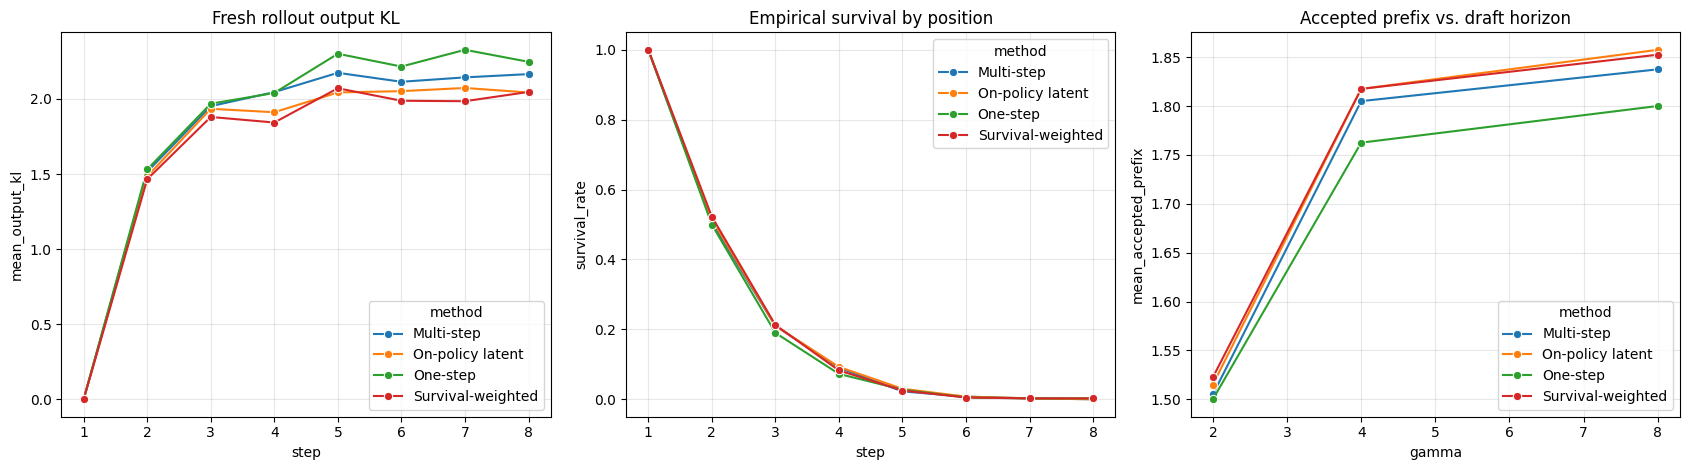

Saved: /content/drive/MyDrive/ma2288_nextlat/results_v2/figures/18_fresh_acceptance_benchmark.png


In [26]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.8),
)

sns.lineplot(
    data=step_summary,
    x="step",
    y="mean_output_kl",
    hue="method",
    marker="o",
    ax=axes[0],
)

axes[0].set_title("Fresh rollout output KL")
axes[0].grid(alpha=0.3)

sns.lineplot(
    data=step_summary,
    x="step",
    y="survival_rate",
    hue="method",
    marker="o",
    ax=axes[1],
)

axes[1].set_title("Empirical survival by position")
axes[1].grid(alpha=0.3)

sns.lineplot(
    data=gamma_summary,
    x="gamma",
    y="mean_accepted_prefix",
    hue="method",
    marker="o",
    ax=axes[2],
)

axes[2].set_title("Accepted prefix vs. draft horizon")
axes[2].grid(alpha=0.3)

plt.tight_layout()

OUTPUT_FIGURE_DIR = (
    PROJECT_DIR
    / "results_v2"
    / "figures"
)

OUTPUT_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    OUTPUT_FIGURE_DIR
    / "18_fresh_acceptance_benchmark.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)

In [27]:
OUTPUT_TABLE_DIR = (
    PROJECT_DIR
    / "results_v2"
    / "tables"
)

OUTPUT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

fresh_record_path = (
    OUTPUT_TABLE_DIR
    / "18_fresh_step_records.csv"
)

fresh_prefix_path = (
    OUTPUT_TABLE_DIR
    / "18_fresh_prefix_records.csv"
)

gamma_summary_path = (
    OUTPUT_TABLE_DIR
    / "18_fresh_gamma_summary.csv"
)

step_summary_path = (
    OUTPUT_TABLE_DIR
    / "18_fresh_step_summary.csv"
)

bootstrap_path = (
    OUTPUT_TABLE_DIR
    / "18_fresh_bootstrap.csv"
)

fresh_record_df.to_csv(
    fresh_record_path,
    index=False,
)

fresh_prefix_df.to_csv(
    fresh_prefix_path,
    index=False,
)

gamma_summary.to_csv(
    gamma_summary_path,
    index=False,
)

step_summary.to_csv(
    step_summary_path,
    index=False,
)

bootstrap_df.to_csv(
    bootstrap_path,
    index=False,
)

print("Saved:")
print(fresh_record_path)
print(fresh_prefix_path)
print(gamma_summary_path)
print(step_summary_path)
print(bootstrap_path)

Saved:
/content/drive/MyDrive/ma2288_nextlat/results_v2/tables/18_fresh_step_records.csv
/content/drive/MyDrive/ma2288_nextlat/results_v2/tables/18_fresh_prefix_records.csv
/content/drive/MyDrive/ma2288_nextlat/results_v2/tables/18_fresh_gamma_summary.csv
/content/drive/MyDrive/ma2288_nextlat/results_v2/tables/18_fresh_step_summary.csv
/content/drive/MyDrive/ma2288_nextlat/results_v2/tables/18_fresh_bootstrap.csv
